# Stage 6 — Relative Karst Vulnerability / Risk (Mole Creek prototype)

The prototype's main output: combines Stage 4 (intrinsic karst vulnerability) × Stage 5 (land-use pressure, 2020) into a single risk surface, the *karst land-use pressure risk index*, or *relative karst vulnerability under land-use pressure*.

**Weighting:** the combination is an unweighted product, i.e. equal implicit weight on vulnerability and pressure. Risk = Hazard × Exposure is the standard multiplicative risk formulation in the hazard literature (e.g. UNISDR/IPCC disaster-risk framing) and matches COP's multiplicative structure (see the Framework section of the project scope doc). A two-factor multiplicative model has nothing to normalise across, so it does not need AHP-style weights the way a weighted-sum (WLC) model does. Stage 9 tests alternative weight emphases.

Once the result looks geographically sensible, the method is **frozen** here before scaling statewide (Stage 7).

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import classify_fixed, aggregate_pressure_by_system, in_mole_creek_focus, mole_creek_focus_mask
from mapping import add_attribution, add_basemap, add_north_arrow, add_risk_colourbar, add_scalebar, label_values, plot_risk, plot_risk_continuous, raster_extent, risk_legend, style_map_axes

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "intrinsic_vulnerability_raw_mc_EPSG7855.tif") as src:
    intrinsic = src.read(1)
    intrinsic_nodata = src.nodata
    profile = src.profile
    transform = src.transform
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure = src.read(1).astype(float)
    pressure_nodata = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# The 3 km buffer is the computation extent (catchment land use needs it), but results are
# reported for the Mole Creek karst only; neighbouring karst in the buffer is context.
focus = mole_creek_focus_mask(karst_mc, intrinsic.shape, transform)
valid = (intrinsic != intrinsic_nodata) & (pressure != pressure_nodata) & focus

## 6.1 Catchment-aggregated pressure

Risk = intrinsic vulnerability × pressure is a per-cell product. Catchment-only polygons have `karst_intensity` = 0, so their intrinsic vulnerability, and therefore their contribution to risk, is always 0, however much high-pressure land they contain. The Stage 0 buffer gives Mole Creek real surrounding land so that a catchment's land use can affect the karst it drains into.

26.8% of high-pressure cells at Mole Creek sit in zero-intensity (catchment-only) polygons.

`aggregate_pressure_by_system()` (see `src/karst.py`) replaces each karst cell's pressure with the mean pressure across its whole named system: the karst polygon(s) *and* the catchment polygons that share the same `KNAME`. Catchment land use then reaches the karst, not just the pixel directly on top of it. This is a simple mean, not a flow-routed or distance-weighted aggregation, which is a limitation.

**Grouping rules:**
- `KNAME` is blank for 5 polygons at Mole Creek (454 statewide). Each blank-name polygon is its own single-feature system.
- The same name is sometimes reused for unrelated, distant polygons (statewide, "Several" spans 233 km and "Various" spans 104 km). Within a name, only polygons within 1 km of each other (chained) are pooled. This keeps contiguous systems whole: Mole Creek itself (73 polygons over 37 km) stays one system even at a 500 m threshold.

**Side effect:** every karst cell in a system gets the *same* pressure value (the system mean), so within-system variation in land use is lost and the risk map is patchier by system. This is the trade-off for letting catchment pressure reach the karst. For `discussion.md`.

In [2]:
effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, pressure_nodata)

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity_check = src.read(1)
karst_cells = (intensity_check > 0) & focus
print(f"Mean pressure at karst cells, pixel-only:  {pressure[karst_cells & valid].mean():.3f}")
print(f"Mean pressure at karst cells, catchment-aggregated: {effective_pressure[karst_cells & valid].mean():.3f}")

Mean pressure at karst cells, pixel-only:  1.995
Mean pressure at karst cells, catchment-aggregated: 1.433


## 6.2 Combine

Risk = Intrinsic vulnerability × catchment-aggregated pressure. Results are reported for the **Mole Creek karst only**. The 3 km buffer stays as the computation extent, because catchment land use needs the surrounding land, but the neighbouring systems inside it (Lorinna, Stockers Plain, Quamby Brook, Golden Valley) are context and are masked out of the risk rasters, maps and rankings (`mole_creek_focus_mask()` in `src/karst.py`).

2020 used as the primary/current year -- 2010 stays available for the Stage 9 temporal comparison, not duplicated here.

In [3]:
pressure_norm = effective_pressure / 3.0  # Stage 5's max pressure score
risk = np.where(valid, intrinsic * pressure_norm, np.nan)

present = np.unique(risk[valid])
print(f"Distinct risk values present ({len(present)}):", present)

Distinct risk values present (6): [0.14341656 0.23580882 0.31441177 0.35371323 0.47161764 0.48390448]


## 6.3 Classify

Catchment-aggregated pressure makes risk a near-continuous score (a mean over many pixels, not one of 3 discrete values), so there can be dozens of distinct values and classifying on every exact value (Stage 4's approach) no longer fits. `classify_fixed()` uses fixed, equal-width classes on the 0-1 scale (edges 0.2, 0.4, 0.6, 0.8), with exact 0 kept as its own "None" class. Fixed edges mean a label covers the same score range at Mole Creek and statewide, and a class such as "Very High" stays empty when no cell reaches it. Quantile bins would always fill every class, however low the scores were.

Class distribution:
  None: 0 cells (0.0%)
  Very Low: 24111 cells (5.8%)
  Low: 284152 cells (68.9%)
  Moderate: 104241 cells (25.3%)
  High: 0 cells (0.0%)
  Very High: 0 cells (0.0%)

Class edges used: ['0.2000', '0.4000', '0.6000', '0.8000']


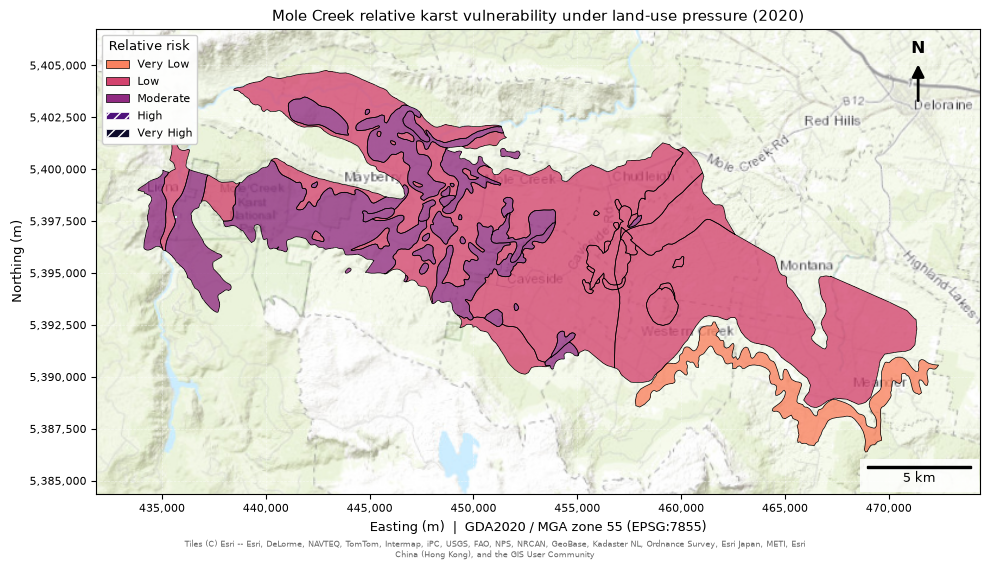

In [4]:
risk_class, edges, LABELS = classify_fixed(risk, valid)
present = edges

print("Class distribution:")
for i, label in enumerate(LABELS):
    n = (risk_class == i).sum()
    print(f"  {label}: {n} cells ({n/valid.sum()*100:.1f}%)")
print("\nClass edges used:", [f"{e:.4f}" for e in edges])

out_profile = profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "risk_class_mc_2020_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(risk_class, 1)

risk_out = np.where(valid, risk, -9999).astype("float32")
raw_profile = profile.copy()
raw_profile.update(dtype="float32", nodata=-9999)
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif", "w", **raw_profile) as dst:
    dst.write(risk_out, 1)

karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, karst_only.total_bounds, zoom=11)
plot_risk(ax, risk_class, transform)
karst_only.boundary.plot(ax=ax, color="black", lw=0.5, zorder=4)
ax.set_title("Mole Creek relative karst vulnerability under land-use pressure (2020)", fontsize=11)
risk_legend(ax, LABELS)
style_map_axes(ax)
add_scalebar(ax, 5000)
add_north_arrow(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


## 6.4 Does this make geographic sense?

Per the plan, the result is checked before the method is frozen. Mean risk by named karst area (`KNAME`) is a natural check.

**Limitation:** this check is not fully independent. Risk is partly derived from `KCATEGORY`, the same field used to name and rank these areas, so "the most intensely karstified areas rank highest" is close to guaranteed by construction. With only 3 named areas in the Mole Creek focus and no independent signal (e.g. cave or doline density from KID), the check confirms that the combination arithmetic behaves as intended, not that the model is validated.

**Aggregation:** all polygons sharing a name are masked together in one operation, giving one pixel-pooled mean per name. This matches Stage 8's method.

In [5]:
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)].copy()

rows = []
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    for name, group in karst_only.groupby("KNAME"):
        out_image, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
        vals = out_image[0]
        vals = vals[vals != -9999]
        rows.append({"KNAME": name, "mean_risk": vals.mean() if len(vals) else np.nan, "n_pixels": len(vals)})

named_risk = pd.DataFrame(rows).sort_values("mean_risk", ascending=False)
print("Named karst areas ranked by mean risk (pooled pixels, not mean-of-polygon-means):")
print(named_risk.to_string(index=False))

Named karst areas ranked by mean risk (pooled pixels, not mean-of-polygon-means):
                       KNAME  mean_risk  n_pixels
Mole Creek  (Chudleigh Hill)   0.483904       214
                  Mole Creek   0.339466    388179
     Meander - Western Creek   0.143417     24111


**Result:** "Mole Creek (Chudleigh Hill)" (0.48), the most intensely karstified system, ranks above "Mole Creek" (0.34), and "Meander - Western Creek" (0.14) is lowest of the three. The check remains partly circular, for the reason above.

**The method is frozen from here.** Per the plan, Stage 7 applies this workflow statewide without re-tuning.

## 6.5 Companion map: continuous risk

The classed map above answers "which areas are in which class"; this one shows the same 0-1 score on a continuous colour ramp, on the same fixed 0-1 scale, so the colours mean the same at every scale. The colourbar is marked at the class edges. Mean risk is written on each named area so the value can be read without matching a colour to the bar; this matters for colour-blind readers, who can see the ordering but may struggle to match a mid-tone to a position on the colourbar.


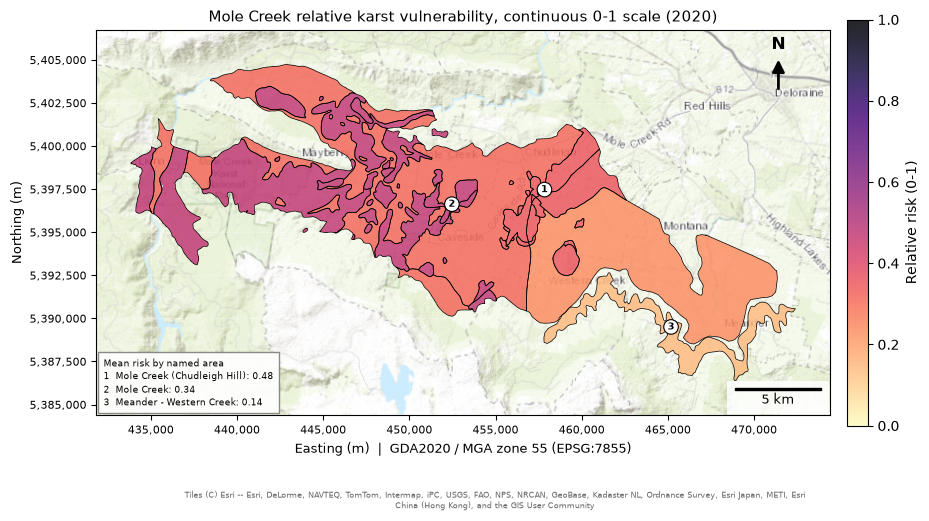

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, karst_only.total_bounds, zoom=11)
image = plot_risk_continuous(ax, risk, transform)
karst_only.boundary.plot(ax=ax, color="black", lw=0.5, zorder=4)
label_values(ax, karst_only, "KNAME", named_risk.set_index("KNAME")["mean_risk"])
add_risk_colourbar(ax, image)
ax.set_title("Mole Creek relative karst vulnerability, continuous 0-1 scale (2020)", fontsize=11)
style_map_axes(ax)
add_scalebar(ax, 5000)
add_north_arrow(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Stage 6 outputs

- `risk_mc_2020_EPSG7855.tif` — continuous risk score
- `risk_class_mc_2020_EPSG7855.tif` — classified risk (labels printed above)

**Next (Stage 7):** apply the frozen method statewide at coarser
resolution.